<a href="https://colab.research.google.com/github/vic-fmr/ecommerce-analytics/blob/main/codigo/analise_ecommerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1 - Setup
---

Está seção é responsavel por setar tudo que é necessário para o projeto rodar, como clone e leitura de arquivos.

---

## 1.1. Configuração (Clone e Imports)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Clonando/Atualizando repo para ter acesso a pasta dados/")

repo_path = "ecommerce-analytics"

if os.path.exists(repo_path):
    print(f"Repositório '{repo_path}' já existe. Executando git pull...")
    !cd {repo_path} && git pull
else:
    print(f"Repositório '{repo_path}' não encontrado. Clonando...")
    !git clone https://github.com/vic-fmr/ecommerce-analytics.git

Clonando/Atualizando repo para ter acesso a pasta dados/
Repositório 'ecommerce-analytics' não encontrado. Clonando...
Cloning into 'ecommerce-analytics'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (66/66), done.
remote: Total 92 (delta 29), reused 15 (delta 2), pack-reused 22 (from 2)
Receiving objects: 100% (92/92), 42.46 MiB | 14.96 MiB/s, done.
Resolving deltas: 100% (29/29), done.


## 1.2. Carga dos DataFrames

In [3]:
DATA_PATH = "/content/ecommerce-analytics/dados"

arquivos = {
    "clientes": "DIM_Customer.csv",
    "entregas": "DIM_Delivery.csv",
    "produtos": "DIM_Products.csv",
    "pedidos": "FACT_Orders.csv",
    "compras": "DIM_Shopping.csv",
}

dataframes = {}

## 1.3. Exploração Inicial (info(), head())

In [32]:
print("--- 1. Carregando Datasets ---")

# Carrega cada arquivo CSV e armazena no dicionário 'dataframes'
for nome, arquivo in arquivos.items():
    caminho_completo = os.path.join(DATA_PATH, arquivo)
    try:
        dataframes[nome] = pd.read_csv(caminho_completo, encoding='utf-8') # Alterado para encoding='utf-8'
        print(f"✅ Arquivo '{arquivo}' carregado com sucesso como 'dataframes['{nome}']'.")
    except FileNotFoundError:
        print(f"❌ ERRO: Arquivo '{arquivo}' não encontrado no caminho '{caminho_completo}'.")
        print("Por favor, verifique o DATA_PATH e o nome do arquivo.")
    except UnicodeDecodeError:
        print(f"⚠️ ERRO de Codificação: Arquivo '{arquivo}' não pôde ser decodificado com 'utf-8'. Tentando 'latin1'.")
        try:
            dataframes[nome] = pd.read_csv(caminho_completo, encoding='latin1')
            print(f"✅ Arquivo '{arquivo}' carregado com sucesso como 'dataframes['{nome}']' usando 'latin1'.")
        except Exception as e:
            print(f"❌ ERRO: Arquivo '{arquivo}' não pôde ser carregado com 'latin1' também. Erro: {e}")
    except Exception as e:
        print(f"❌ ERRO ao carregar arquivo '{arquivo}': {e}")

print("\n--- 2. Exploração Inicial (Shape, Colunas, Tipos e Nulos) ---")


def explorar_df(nome, df):
    print("\n" + "="*50)
    print(f" DataFrame: {nome}")
    print(f" Formato (Linhas, Colunas): {df.shape}")
    print("="*50)

    print(f"\n[Info: Colunas, Contagem de Nulos e Tipos de Dados]")
    df.info()

    print(f"\n[Head: 3 primeiras linhas]")
    display(df.head(3))
    print("\n")


# Se os dataframes foram carregados, executa a exploração
if dataframes:
    for nome, df in dataframes.items():
        explorar_df(nome, df)
else:
    print("Nenhum dataframe foi carregado. A exploração foi interrompida.")

--- 1. Carregando Datasets ---
✅ Arquivo 'DIM_Customer.csv' carregado com sucesso como 'dataframes['clientes']'.
✅ Arquivo 'DIM_Delivery.csv' carregado com sucesso como 'dataframes['entregas']'.
✅ Arquivo 'DIM_Products.csv' carregado com sucesso como 'dataframes['produtos']'.
✅ Arquivo 'FACT_Orders.csv' carregado com sucesso como 'dataframes['pedidos']'.
✅ Arquivo 'DIM_Shopping.csv' carregado com sucesso como 'dataframes['compras']'.

--- 2. Exploração Inicial (Shape, Colunas, Tipos e Nulos) ---

 DataFrame: clientes
 Formato (Linhas, Colunas): (2000, 6)

[Info: Colunas, Contagem de Nulos e Tipos de Dados]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Id             2000 non-null   int64 
 1   Customer_Id    2000 non-null   object
 2   Customer_Name  2000 non-null   object
 3   City           2000 non-null   object
 4   State          20

,Id,Customer_Id,Customer_Name,City,State,Region
0,1,C00001,Catarina Oliveira,Sena Madureira,AC,Norte
1,2,C00002,Igor Cunha,Campina Grande,PB,Nordeste
2,3,C00003,Isis Barbosa,Cantá,RR,Norte





 DataFrame: entregas
 Formato (Linhas, Colunas): (2000, 7)

[Info: Colunas, Contagem de Nulos e Tipos de Dados]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Id           2000 non-null   int64  
 1   Delivery_Id  2000 non-null   object 
 2   Services     2000 non-null   object 
 3   P_Sevice     2000 non-null   float64
 4   D_Forecast   2000 non-null   object 
 5   D_Date       2000 non-null   object 
 6   Status       2000 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 109.5+ KB

[Head: 3 primeiras linhas]


,Id,Delivery_Id,Services,P_Sevice,D_Forecast,D_Date,Status
0,1,D00001,Same-Day,42.9,2025-05-03 14:45:17,2025-05-03 14:45:17,A Caminho
1,2,D00002,Same-Day,42.9,2025-05-14 07:31:07,2025-05-17 07:31:07,Entregue
2,3,D00003,Standard,22.9,2025-05-10 15:29:43,2025-05-10 15:29:43,A Caminho





 DataFrame: produtos
 Formato (Linhas, Colunas): (21, 6)

[Info: Colunas, Contagem de Nulos e Tipos de Dados]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            21 non-null     int64  
 1   Product_Id    21 non-null     object 
 2   Product_Name  21 non-null     object 
 3   Category      21 non-null     object 
 4   Subcategory   21 non-null     object 
 5   Price         21 non-null     float64
dtypes: float64(1), int64(1), object(4)
memory usage: 1.1+ KB

[Head: 3 primeiras linhas]


...

,Id,Order_Date,Discount,Subtotal,Total,payment,Purchase_Status
0,1,2025-04-12 00:52:33,0.1048,3958.20,3586.28,Credito,Processando
1,2,2025-05-05 01:02:38,0.1141,1799.01,1636.64,PIX,Em Analise
2,3,2025-04-27 23:05:38,0.0686,2144.00,2019.82,Boleto,Cancelado





 DataFrame: compras
 Formato (Linhas, Colunas): (2000, 5)

[Info: Colunas, Contagem de Nulos e Tipos de Dados]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        2000 non-null   int64  
 1   Item_ID   2000 non-null   object 
 2   Product   2000 non-null   object 
 3   Quantity  2000 non-null   int64  
 4   Price     2000 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 78.3+ KB

[Head: 3 primeiras linhas]


,Id,Item_ID,Product,Quantity,Price
0,1,I00001,Samsung Galaxy A36,2,1979.10
1,2,I00002,Samsung Galaxy Tab S6 Lite,1,1799.01
2,3,I00003,"Soundbar Samsung com 2.1 canais, Dolby Digital",2,1072.00





 DataFrame: df_master
 Formato (Linhas, Colunas): (2000, 33)

[Info: Colunas, Contagem de Nulos e Tipos de Dados]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Order_ID                2000 non-null   int64         
 1   Order_Date              2000 non-null   datetime64[ns]
 2   Discount                2000 non-null   float64       
 3   Subtotal                2000 non-null   float64       
 4   Total                   2000 non-null   float64       
 5   payment                 2000 non-null   object        
 6   Purchase_Status         2000 non-null   object        
 7   Delivery_Id             2000 non-null   object        
 8   Services                2000 non-null   object        
 9   P_Sevice                2000 non-null   float64       
 10  D_Forecast              2000 non-null   datetime64[

,Order_ID,Order_Date,Discount,Subtotal,Total,payment,Purchase_Status,Delivery_Id,Services,P_Sevice,...,Product_Name_catalog,Category,Subcategory,Product_Price_catalog,delivery_delay_days,delivery_lead_time,is_late,is_confirmed,freight_share,discount_abs
0,1,2025-04-12 00:52:33,0.1048,3958.20,3586.28,credito,processando,d00001,same-day,42.9,...,Samsung Galaxy A36,EletrÃ´nicos,"Celulares, Tablets e AcessÃ³rios",1979.10,0,21,0,0,0.011962,414.819360
1,2,2025-05-05 01:02:38,0.1141,1799.01,1636.64,pix,em analise,d00002,same-day,42.9,...,Samsung Galaxy Tab S6 Lite,EletrÃ´nicos,"Celulares, Tablets e AcessÃ³rios",1799.01,3,12,1,0,0.026212,205.267041
2,3,2025-04-27 23:05:38,0.0686,2144.00,2019.82,boleto,cancelado,d00003,standard,22.9,...,Carregador Turbo USB-C 30W,EletrÃ´nicos,"Celulares, Tablets e AcessÃ³rios",49.90,0,12,0,0,0.011338,147.078400


# 2. [S1] Data Cleaning (Tipos, NAs, Strings)
---

Seção de limpeza e verificação de dados.

---

## 2.1. Correção de Tipos (Datas e Numéricos)

In [ ]:
print("\n--- 2.1. Correção de Tipos: Datas ---")

colunas_de_data = {
    'entregas': ['D_Forecast', 'D_Date'],
    'pedidos': ['Order_Date']
}

for nome_df, df in dataframes.items():
    if nome_df in colunas_de_data:
        print(f"\n🚀 Processando DataFrame: {nome_df}")

        # Filtrar apenas as colunas que realmente existem no DataFrame
        colunas_para_converter = [col for col in colunas_de_data[nome_df] if col in df.columns]

        if colunas_para_converter:
            print(f"   Colunas identificadas para conversão: {colunas_para_converter}")

            for col in colunas_para_converter:
                # O parâmetro 'errors='coerce'' transformará valores que não são datas válidas em NaT (Not a Time/Date),
                # o que facilita a identificação e tratamento de erros posteriormente.
                df[col] = pd.to_datetime(df[col], errors='coerce')
                print(f"   ✅ Coluna '{col}' convertida para tipo datetime64[ns].")

            dataframes[nome_df] = df
        else:
            print(f"   Nenhuma coluna de data predefinida encontrada em '{nome_df}'.")
    else:
        print(f"\n   DataFrame '{nome_df}' não possui colunas de data pré-mapeadas neste passo.")

#Re-executar a exploração para ver os novos tipos
print("\n" + "="*70)
print("\n🚀Re-executando exploração de dataframes com colunas de data após:")
for nome, df in dataframes.items():
    if nome in colunas_de_data:
        explorar_df(nome, df)

print("\n" + "="*70)
print("\n--- 2.1. Correção de Tipos: Numéricos ---")

colunas_numericas = {
    'clientes': ['Id'],
    'entregas': ['Id', 'P_Sevice'],
    'produtos': ['Id', 'Price'],
    'pedidos': ['Id', 'Discount', 'Subtotal', 'Total'],
    'compras': ['Id', 'Quantity', 'Price']
}

for nome_df, df in dataframes.items():
    if nome_df in colunas_numericas:
        print(f"\n🚀 Processando DataFrame: {nome_df}")

        # Filtrar apenas as colunas que realmente existem no DataFrame
        colunas_para_converter = [col for col in colunas_numericas[nome_df] if col in df.columns]

        if colunas_para_converter:
            for col in colunas_para_converter:
                # Converte para float, o parâmetro 'errors='coerce'' transforma
                # qualquer valor que não seja numérico em NaN (Not a Number).
                df[col] = pd.to_numeric(df[col], errors='coerce')
                print(f"   ✅ Coluna '{col}' convertida para tipo numérico (float64) com erros forçados a NaN.")

            dataframes[nome_df] = df
        else:
            print(f"   Nenhuma coluna numérica predefinida encontrada em '{nome_df}'.")


--- 2.1. Correção de Tipos: Datas ---

   DataFrame 'clientes' não possui colunas de data pré-mapeadas neste passo.

🚀 Processando DataFrame: entregas
   Colunas identificadas para conversão: ['D_Forecast', 'D_Date']
   ✅ Coluna 'D_Forecast' convertida para tipo datetime64[ns].
   ✅ Coluna 'D_Date' convertida para tipo datetime64[ns].

   DataFrame 'produtos' não possui colunas de data pré-mapeadas neste passo.

🚀 Processando DataFrame: pedidos
   Colunas identificadas para conversão: ['Order_Date']
   ✅ Coluna 'Order_Date' convertida para tipo datetime64[ns].

   DataFrame 'compras' não possui colunas de data pré-mapeadas neste passo.


🚀Re-executando exploração de dataframes com colunas de data após:

 DataFrame: entregas
 Formato (Linhas, Colunas): (2000, 7)

[Info: Colunas, Contagem de Nulos e Tipos de Dados]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       -

,Id,Delivery_Id,Services,P_Sevice,D_Forecast,D_Date,Status
0,1,D00001,Same-Day,42.9,2025-05-03 14:45:17,2025-05-03 14:45:17,A Caminho
1,2,D00002,Same-Day,42.9,2025-05-14 07:31:07,2025-05-17 07:31:07,Entregue
2,3,D00003,Standard,22.9,2025-05-10 15:29:43,2025-05-10 15:29:43,A Caminho





 DataFrame: pedidos
 Formato (Linhas, Colunas): (2000, 7)

[Info: Colunas, Contagem de Nulos e Tipos de Dados]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Id               2000 non-null   int64         
 1   Order_Date       2000 non-null   datetime64[ns]
 2   Discount         2000 non-null   float64       
 3   Subtotal         2000 non-null   float64       
 4   Total            2000 non-null   float64       
 5   payment          2000 non-null   object        
 6   Purchase_Status  2000 non-null   object        
dtypes: datetime64[ns](1), float64(3), int64(1), object(2)
memory usage: 109.5+ KB

[Head: 3 primeiras linhas]


,Id,Order_Date,Discount,Subtotal,Total,payment,Purchase_Status
0,1,2025-04-12 00:52:33,0.1048,3958.20,3586.28,Credito,Processando
1,2,2025-05-05 01:02:38,0.1141,1799.01,1636.64,PIX,Em Analise
2,3,2025-04-27 23:05:38,0.0686,2144.00,2019.82,Boleto,Cancelado






--- 2.1. Correção de Tipos: Numéricos ---

🚀 Processando DataFrame: clientes
   ✅ Coluna 'Id' convertida para tipo numérico (float64) com erros forçados a NaN.

🚀 Processando DataFrame: entregas
   ✅ Coluna 'Id' convertida para tipo numérico (float64) com erros forçados a NaN.
   ✅ Coluna 'P_Sevice' convertida para tipo numérico (float64) com erros forçados a NaN.

🚀 Processando DataFrame: produtos
   ✅ Coluna 'Id' convertida para tipo numérico (float64) com erros forçados a NaN.
   ✅ Coluna 'Price' convertida para tipo numérico (float64) com erros forçados a NaN.

🚀 Processando DataFrame: pedidos
   ✅ Coluna 'Id' convertida para tipo numérico (float64) com erros forçados a NaN.
   ✅ Coluna 'Discount' convertida para tipo numérico (float64) com erros forçados a NaN.
   ✅ Coluna 'Subtotal' convertida para tipo numérico (float64) com erros forçados a NaN.
   ✅ Coluna 'Total' convertida para tipo numérico (float64) com erros forçados a NaN.

🚀 Processando DataFrame: compras
   ✅ Colun

## 2.2. Tratamento Estratégico de Nulos

In [ ]:
print("\n" + "="*70)
print("--- 2.2. Análise de Valores Ausentes (NaN/NaT) ---")
print("="*70)

def identificar_nulos(df, nome_df):
    """
    Calcula a contagem e o percentual de valores nulos para cada coluna.
    """
    nulos = df.isnull().sum()
    total_linhas = len(df)

    # Criar um DataFrame de resumo apenas para colunas com nulos
    nulos_df = pd.DataFrame({
        'Contagem de Nulos': nulos,
        'Percentual (%)': (nulos / total_linhas) * 100
    }).sort_values(by='Contagem de Nulos', ascending=False)

    # Filtrar apenas as colunas que realmente possuem valores nulos (> 0)
    # ─ CORREÇÃO: Usar .copy() para garantir que nulos_principais é um novo DataFrame
    nulos_principais = nulos_df[nulos_df['Contagem de Nulos'] > 0].copy()

    print(f"\n--- Resumo de Nulos no DataFrame: {nome_df} ({total_linhas} linhas) ---")

    if nulos_principais.empty:
        print("✅ Não foram encontrados valores ausentes (NaN/NaT) neste DataFrame.")
    else:
        nulos_principais['Percentual (%)'] = nulos_principais['Percentual (%)'].map('{:.2f}%'.format)
        display(nulos_principais)

        print("\nPróxima etapa: **Investigar Causa, Validar Hipótese e Documentar Decisão** para cada coluna listada.")

if dataframes:
    for nome, df in dataframes.items():
        identificar_nulos(df, nome)



--- 2.2. Análise de Valores Ausentes (NaN/NaT) ---

--- Resumo de Nulos no DataFrame: clientes (2000 linhas) ---
✅ Não foram encontrados valores ausentes (NaN/NaT) neste DataFrame.

--- Resumo de Nulos no DataFrame: entregas (2000 linhas) ---
✅ Não foram encontrados valores ausentes (NaN/NaT) neste DataFrame.

--- Resumo de Nulos no DataFrame: produtos (21 linhas) ---
✅ Não foram encontrados valores ausentes (NaN/NaT) neste DataFrame.

--- Resumo de Nulos no DataFrame: pedidos (2000 linhas) ---
✅ Não foram encontrados valores ausentes (NaN/NaT) neste DataFrame.

--- Resumo de Nulos no DataFrame: compras (2000 linhas) ---
✅ Não foram encontrados valores ausentes (NaN/NaT) neste DataFrame.


##2.3. Padronização de Texto (Strings)

In [ ]:
print("\n" + "="*70)
print("--- 2.3. Padronização de Texto (Strings) ---")
print("="*70)

# Mapeamento de DataFrames e suas colunas de texto para padronizar
# Inclua aqui as colunas que você sabe que contêm strings e precisam de limpeza
colunas_para_padronizar = {
    'clientes': ['Customer_Id', 'Customer_Name', 'City', 'State', 'Region'],
    'entregas': ['Delivery_Id', 'Services', 'Status'],
    'produtos': ['Product_Id', 'Product_Name', 'Category', 'Subcategory'],
    'pedidos': ['payment', 'Purchase_Status'],
    'compras': ['Item_ID', 'Product']
}

for nome_df, df in dataframes.items():
    if nome_df in colunas_para_padronizar:
        print(f"\n🚀 Processando DataFrame: {nome_df}")
        for col in colunas_para_padronizar[nome_df]:
            if col in df.columns and df[col].dtype == 'object': # Verifica se a coluna existe e é do tipo object (string)
                # Aplica strip() e lower() e lida com possíveis valores não-string
                df[col] = df[col].astype(str).str.strip().str.lower()
                print(f"   ✅ Coluna '{col}' padronizada (minúsculas e sem espaços extras).")

                # Verificação adicional para consistência de valores únicos, útil para colunas 'status' ou 'category'
                if 'status' in col.lower() or 'category' in col.lower() or 'city' in col.lower():
                    status_unicos_antes = df[col].unique()
                    print(f"      Valores únicos em '{col}' após padronização: {status_unicos_antes[:5]}... ({len(status_unicos_antes)} únicos)")
            elif col in df.columns:
                print(f"   ⚠️ Coluna '{col}' existe, mas não é do tipo string. Pulando padronização.")
            else:
                print(f"   ❌ Coluna '{col}' não encontrada no DataFrame '{nome_df}'. Pulando.")
    else:
        print(f"\n   DataFrame '{nome_df}' não possui colunas mapeadas para padronização neste passo.")

print("\n--- Verificação Final de Padronização (Amostras) ---")
# Exibir amostras para algumas colunas padronizadas para verificação
if 'clientes' in dataframes and 'City' in dataframes['clientes'].columns:
    print("\nExemplo de 'City' em 'clientes':")
    display(dataframes['clientes']['City'].head())

if 'produtos' in dataframes and 'Category' in dataframes['produtos'].columns:
    print("\nExemplo de 'Category' em 'produtos':")
    display(dataframes['produtos']['Category'].head())

if 'pedidos' in dataframes and 'Purchase_Status' in dataframes['pedidos'].columns:
    print("\nExemplo de 'Purchase_Status' em 'pedidos':")
    display(dataframes['pedidos']['Purchase_Status'].head())


--- 2.3. Padronização de Texto (Strings) ---

🚀 Processando DataFrame: clientes
   ✅ Coluna 'Customer_Id' padronizada (minúsculas e sem espaços extras).
   ✅ Coluna 'Customer_Name' padronizada (minúsculas e sem espaços extras).
   ✅ Coluna 'City' padronizada (minúsculas e sem espaços extras).
      Valores únicos em 'City' após padronização: ['sena madureira' 'campina grande' 'cantá' 'cacoal' 'rio branco']... (109 únicos)
   ✅ Coluna 'State' padronizada (minúsculas e sem espaços extras).
   ✅ Coluna 'Region' padronizada (minúsculas e sem espaços extras).

🚀 Processando DataFrame: entregas
   ✅ Coluna 'Delivery_Id' padronizada (minúsculas e sem espaços extras).
   ✅ Coluna 'Services' padronizada (minúsculas e sem espaços extras).
   ✅ Coluna 'Status' padronizada (minúsculas e sem espaços extras).
      Valores únicos em 'Status' após padronização: ['a caminho' 'entregue' 'trânsito' 'atrasado']... (4 únicos)

🚀 Processando DataFrame: produtos
   ✅ Coluna 'Product_Id' padronizada (minúsc

,City
0,sena madureira
1,campina grande
2,cantá
3,cacoal
4,rio branco



Exemplo de 'Category' em 'produtos':


,Category
0,eletrônicos
1,eletrônicos
2,eletrônicos
3,eletrônicos
4,eletrônicos



Exemplo de 'Purchase_Status' em 'pedidos':


,Purchase_Status
0,processando
1,em analise
2,cancelado
3,processando
4,em analise


# 3. [S1] Validação de Chaves e Unicidade
---

Esta seção garante que as chaves primárias das tabelas estejam íntegras, ou seja, que cada coluna designada como chave não possua valores duplicados. Isso é fundamental para evitar a contagem dupla de pedidos ou clientes nas análises futuras.

---

In [ ]:
print("\n" + "="*70)
print("--- 3. Validação de Chaves Primárias e Unicidade ---")
print("="*70)

# Dicionário de chaves a serem verificadas
chaves_a_verificar = {
    'clientes': 'Id',
    'entregas': 'Id',
    'produtos': 'Id',
    'pedidos': 'Id',
    'compras': 'Id',
}

# --- Checagem de Unicidade ---
print("## 3.1. Validação de Chaves Simples (PKs)")
print("-" * 50)

for nome_df, coluna_chave in chaves_a_verificar.items():
    df = dataframes[nome_df]
    duplicadas_count = df[coluna_chave].duplicated().sum()

    # Regra geral para PKs
    if duplicadas_count > 0:
        print(f"❌ **ERRO GRAVE:** Tabela {nome_df} tem {duplicadas_count} duplicatas na chave '{coluna_chave}'.")
        print("É necessário investigar e remover as duplicatas.")
    else:
        print(f"✅ Tabela {nome_df}: A chave '{coluna_chave}' está **100% ÚNICA**.")

# --- Conclusão da Validação ---
print("\n## 3.2. Conclusão da Validação")
print("-" * 50)
print("A integridade das chaves primárias principais foi confirmada, garantindo a unicidade dos dados para as próximas etapas de agregação e análise.")


--- 3. Validação de Chaves Primárias e Unicidade ---
## 3.1. Validação de Chaves Simples (PKs)
--------------------------------------------------
✅ Tabela clientes: A chave 'Id' está **100% ÚNICA**.
✅ Tabela entregas: A chave 'Id' está **100% ÚNICA**.
✅ Tabela produtos: A chave 'Id' está **100% ÚNICA**.
✅ Tabela pedidos: A chave 'Id' está **100% ÚNICA**.
✅ Tabela compras: A chave 'Id' está **100% ÚNICA**.

## 3.2. Conclusão da Validação
--------------------------------------------------
A integridade das chaves primárias principais foi confirmada, garantindo a unicidade dos dados para as próximas etapas de agregação e análise.


# 4 - Detecção e Documentação de Outliers
---

Esta seção foca na identificação e documentação de valores discrepantes (outliers) em colunas numéricas dos DataFrames, utilizando o método do Intervalo Interquartil (IQR). O objetivo é entender a distribuição dos dados e propor decisões iniciais sobre o tratamento desses outliers, sem removê-los automaticamente.

---

In [ ]:
print("\n" + "="*70)
print("--- Detecção e Documentação de Outliers (Método IQR) ---")
print("="*70)

def detect_and_document_outliers_iqr(df, column_name, df_name="Unnamed DataFrame"):
    """
    Detecta e documenta outliers em uma coluna numérica de um DataFrame usando o método IQR.

    Args:
        df (pd.DataFrame): O DataFrame a ser analisado.
        column_name (str): O nome da coluna numérica para detectar outliers.
        df_name (str): Um nome para o DataFrame (para exibição).
    """
    print(f"\n🚀 Analisando o DataFrame '{df_name}', Coluna: '{column_name}'")

    # Certifica-se de que a coluna é numérica e lida com NaNs
    if not pd.api.types.is_numeric_dtype(df[column_name]):
        print(f"   ❌ A coluna '{column_name}' não é numérica. Pulando a análise de outliers.")
        return

    # Remove NaNs temporariamente para cálculo de IQR para evitar erros
    # e para que o cálculo represente apenas os valores existentes.
    data = df[column_name].dropna()
    if data.empty:
        print(f"   ⚠️ A coluna '{column_name}' não possui dados válidos para análise após remover NaNs. Pulando.")
        return

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]

    num_outliers = len(outliers)
    total_rows = len(df)

    if total_rows == 0: # Evitar divisão por zero
        percent_outliers = 0
    else:
        percent_outliers = (num_outliers / total_rows) * 100

    print(f"   > Limite Inferior (Q1 - 1.5*IQR): {lower_bound:.2f}")
    print(f"   > Limite Superior (Q3 + 1.5*IQR): {upper_bound:.2f}")
    print(f"   > Outliers encontrados: {num_outliers} ({percent_outliers:.2f}% do total de {total_rows} linhas)")

    if num_outliers > 0:
        print(f"   > Amostra de 5 outliers para '{column_name}':")
        display(outliers[[column_name]].head())
        print(f"   > Mínimo: {data.min():.2f}, Máximo: {data.max():.2f}, Média: {data.mean():.2f}, Mediana: {data.median():.2f}")
    else:
        print("   ✅ Nenhum outlier detectado para esta coluna usando o método IQR.")

    # Proposta de decisão inicial (pode ser ajustada manualmente depois)
    print("   > Decisão Inicial Proposta para Outliers:")
    if column_name in ['Price', 'P_Sevice', 'Discount', 'Subtotal', 'Total', 'Quantity']:
        if num_outliers > 0:
            print("     * Manter/Investigar: Valores extremos podem representar transações de alto valor, grandes quantidades ou preços especiais. "
                  "Removê-los pode distorcer métricas importantes. Recomenda-se investigação adicional antes de qualquer tratamento.")
        else:
            print("     * Manter: Nenhum outlier detectado.")
    elif column_name == 'Id':
        if num_outliers > 0:
            print("     * Investigar: Outliers em colunas de ID são incomuns e podem indicar erros nos dados. "
                  "Verificar se são IDs válidos com valores muito discrepantes ou erros de digitação.")
        else:
            print("     * Manter: Nenhum outlier detectado (esperado para IDs).")
    else:
        print("     * Manter: Sem regra específica para esta coluna, assumindo que outliers devem ser mantidos, "
              "mas é recomendada uma investigação mais aprofundada.")

colunas_numericas_outliers = {
    'clientes': ['Id'],
    'entregas': ['Id', 'P_Sevice'],
    'produtos': ['Id', 'Price'],
    'pedidos': ['Id', 'Discount', 'Subtotal', 'Total'],
    'compras': ['Id', 'Quantity', 'Price']
}


# Loop para aplicar a função a todas as colunas especificadas
for df_name, columns in colunas_numericas_outliers.items():
    # Certifica-se de que o DataFrame existe no dicionário 'dataframes'
    if df_name in dataframes:
        df = dataframes[df_name]
        for col in columns:
            # Certifica-se de que a coluna existe no DataFrame
            if col in df.columns:
                detect_and_document_outliers_iqr(df, col, df_name)
            else:
                print(f"   ❌ Coluna '{col}' não encontrada no DataFrame '{df_name}'. Pulando.")
    else:
        print(f"   ❌ DataFrame '{df_name}' não encontrado no dicionário 'dataframes'. Pulando.")


--- Detecção e Documentação de Outliers (Método IQR) ---

🚀 Analisando o DataFrame 'clientes', Coluna: 'Id'
   > Limite Inferior (Q1 - 1.5*IQR): -998.50
   > Limite Superior (Q3 + 1.5*IQR): 2999.50
   > Outliers encontrados: 0 (0.00% do total de 2000 linhas)
   ✅ Nenhum outlier detectado para esta coluna usando o método IQR.
   > Decisão Inicial Proposta para Outliers:
     * Manter: Nenhum outlier detectado (esperado para IDs).

🚀 Analisando o DataFrame 'entregas', Coluna: 'Id'
   > Limite Inferior (Q1 - 1.5*IQR): -998.50
   > Limite Superior (Q3 + 1.5*IQR): 2999.50
   > Outliers encontrados: 0 (0.00% do total de 2000 linhas)
   ✅ Nenhum outlier detectado para esta coluna usando o método IQR.
   > Decisão Inicial Proposta para Outliers:
     * Manter: Nenhum outlier detectado (esperado para IDs).

🚀 Analisando o DataFrame 'entregas', Coluna: 'P_Sevice'
   > Limite Inferior (Q1 - 1.5*IQR): -7.10
   > Limite Superior (Q3 + 1.5*IQR): 72.90
   > Outliers encontrados: 0 (0.00% do total de

,Price
16,4604.0


   > Mínimo: 17.90, Máximo: 4604.00, Média: 1057.95, Mediana: 769.90
   > Decisão Inicial Proposta para Outliers:
     * Manter/Investigar: Valores extremos podem representar transações de alto valor, grandes quantidades ou preços especiais. Removê-los pode distorcer métricas importantes. Recomenda-se investigação adicional antes de qualquer tratamento.

🚀 Analisando o DataFrame 'pedidos', Coluna: 'Id'
   > Limite Inferior (Q1 - 1.5*IQR): -998.50
   > Limite Superior (Q3 + 1.5*IQR): 2999.50
   > Outliers encontrados: 0 (0.00% do total de 2000 linhas)
   ✅ Nenhum outlier detectado para esta coluna usando o método IQR.
   > Decisão Inicial Proposta para Outliers:
     * Manter: Nenhum outlier detectado (esperado para IDs).

🚀 Analisando o DataFrame 'pedidos', Coluna: 'Discount'
   > Limite Inferior (Q1 - 1.5*IQR): -0.07
   > Limite Superior (Q3 + 1.5*IQR): 0.22
   > Outliers encontrados: 0 (0.00% do total de 2000 linhas)
   ✅ Nenhum outlier detectado para esta coluna usando o método IQR.

,Subtotal
7,9208.00
9,9149.97
12,18416.00
33,18416.00
46,13812.00


   > Mínimo: 17.90, Máximo: 18416.00, Média: 2671.55, Mediana: 1286.97
   > Decisão Inicial Proposta para Outliers:
     * Manter/Investigar: Valores extremos podem representar transações de alto valor, grandes quantidades ou preços especiais. Removê-los pode distorcer métricas importantes. Recomenda-se investigação adicional antes de qualquer tratamento.

🚀 Analisando o DataFrame 'pedidos', Coluna: 'Total'
   > Limite Inferior (Q1 - 1.5*IQR): -4591.30
   > Limite Superior (Q3 + 1.5*IQR): 8320.23
   > Outliers encontrados: 130 (6.50% do total de 2000 linhas)
   > Amostra de 5 outliers para 'Total':


,Total
7,9143.39
12,16319.22
33,18117.50
46,13231.32
53,12730.60


   > Mínimo: 38.54, Máximo: 18349.54, Média: 2502.08, Mediana: 1220.79
   > Decisão Inicial Proposta para Outliers:
     * Manter/Investigar: Valores extremos podem representar transações de alto valor, grandes quantidades ou preços especiais. Removê-los pode distorcer métricas importantes. Recomenda-se investigação adicional antes de qualquer tratamento.

🚀 Analisando o DataFrame 'compras', Coluna: 'Id'
   > Limite Inferior (Q1 - 1.5*IQR): -998.50
   > Limite Superior (Q3 + 1.5*IQR): 2999.50
   > Outliers encontrados: 0 (0.00% do total de 2000 linhas)
   ✅ Nenhum outlier detectado para esta coluna usando o método IQR.
   > Decisão Inicial Proposta para Outliers:
     * Manter: Nenhum outlier detectado (esperado para IDs).

🚀 Analisando o DataFrame 'compras', Coluna: 'Quantity'
   > Limite Inferior (Q1 - 1.5*IQR): -2.00
   > Limite Superior (Q3 + 1.5*IQR): 6.00
   > Outliers encontrados: 0 (0.00% do total de 2000 linhas)
   ✅ Nenhum outlier detectado para esta coluna usando o método IQ

,Price
7,4604.0
12,4604.0
33,4604.0
46,4604.0
53,4604.0


   > Mínimo: 17.90, Máximo: 4604.00, Média: 1063.25, Mediana: 769.90
   > Decisão Inicial Proposta para Outliers:
     * Manter/Investigar: Valores extremos podem representar transações de alto valor, grandes quantidades ou preços especiais. Removê-los pode distorcer métricas importantes. Recomenda-se investigação adicional antes de qualquer tratamento.


# 5 - Feature Engineering
---
Nesta seção, foi construído um DataFrame mestre (df_master) através da união de todas as tabelas relevantes. Em seguida, foram criadas novas features conforme as especificações do projeto, como delivery_delay_days, delivery_lead_time, is_late, is_confirmed, freight_share e discount_abs. Este DataFrame mestre consolidado é a base para análises subsequentes.

---

In [38]:
print("\n" + "="*70)
print("--- Engenharia de Features e Criação do DataFrame Mestre ---")
print("="*70)

# 1. Para a engenharia de features, precisamos de um dataframe mestre
# então o criamos através do pd.merge() entre os dataframes, um por um.

# Aqui já inicializamos o df_master usando uma cópia do dataframe 'pedidos'
# então não usamos o pd.merge()
df_master = dataframes['pedidos'].copy()
df_master.rename(columns={'Id': 'Order_ID'}, inplace=True)
print(f"Dataframe base 'df_master' criado a partir de 'pedidos' ({df_master.shape[0]} linhas).")

# Merge com entregas
# Garante que 'Id' em entregas também é 'Order_ID' para o merge.
df_entregas_temp = dataframes['entregas'].copy()
df_entregas_temp.rename(columns={'Id': 'Order_ID'}, inplace=True)
df_master = pd.merge(df_master, df_entregas_temp, on='Order_ID', how='left')
print(f"Merge realizado com 'entregas'. Shape atual: {df_master.shape}")

# Merge com clientes
# Assumindo que 'Id' em clientes corresponde a 'Order_ID' para ligação baseada no contexto do projeto.
# Esta é uma forte suposição, mas necessária dado o esquema.
df_clientes_temp = dataframes['clientes'].copy()
df_clientes_temp.rename(columns={'Id': 'Order_ID', 'Customer_Id': 'Customer_Business_ID'}, inplace=True) # Renomeia Id para Order_ID e Customer_Id para clareza
df_master = pd.merge(df_master, df_clientes_temp[['Order_ID', 'Customer_Business_ID', 'Customer_Name', 'City', 'State', 'Region']], on='Order_ID', how='left')
print(f"Merge realizado com 'clientes'. Shape atual: {df_master.shape}")

# Merge com compras (isso criará múltiplas linhas por pedido se um pedido tiver múltiplos itens)
df_compras_temp = dataframes['compras'].copy()
df_compras_temp.rename(columns={'Id': 'Order_ID', 'Product': 'Product_Name_ordered', 'Price': 'Item_Price_shopping', 'Quantity': 'Item_Quantity_shopping'}, inplace=True)

# FIX: Correct Item_ID prefix and padding to match Product_Id format in products dataframe
# Assuming 'Item_ID' starts with 'i' and 'Product_Id' starts with 'p' and the numeric part is consistent.
df_compras_temp['Item_ID'] = df_compras_temp['Item_ID'].astype(str).str.strip().str.lower().str.replace('i', 'p', regex=False).apply(lambda x: f"p{int(x[1:]):05d}")
print("✅ Corrigido o formato de 'Item_ID' em 'compras' para mesclagem com 'produtos'.")

df_master = pd.merge(df_master, df_compras_temp, on='Order_ID', how='left')
print(f"Merge realizado com 'compras' (detalhe por item). Shape atual: {df_master.shape}")

# Merge com produtos (usando Item_ID de compras e Product_Id de produtos)
# FIX: Reload DIM_Products to get clean Category/Subcategory names, then process IDs for merging
df_produtos_original = pd.read_csv(os.path.join(DATA_PATH, arquivos['produtos']), encoding='utf-8') # Alterado para encoding='utf-8'
df_produtos_temp = df_produtos_original.copy()
df_produtos_temp.rename(columns={'Id': 'Product_PK_ID', 'Product_Name': 'Product_Name_catalog', 'Price': 'Product_Price_catalog'}, inplace=True)

# Ensure Product_Id is clean and padded for merging
df_produtos_temp['Product_Id'] = df_produtos_temp['Product_Id'].astype(str).str.strip().str.lower().apply(lambda x: f"p{int(x[1:]):05d}")
print("✅ Corrigido o formato de 'Product_Id' em 'produtos' para mesclagem.")

# Apply strip to Category and Subcategory, but NOT .lower() to preserve special characters in 'produtos' for proper display/matching
df_produtos_temp['Category'] = df_produtos_temp['Category'].astype(str).str.strip()
df_produtos_temp['Subcategory'] = df_produtos_temp['Subcategory'].astype(str).str.strip()
print("✅ Limpo 'Category' e 'Subcategory' em 'produtos' removendo espaços em branco, preservando a capitalização original.")

df_master = pd.merge(df_master, df_produtos_temp[['Product_Id', 'Product_PK_ID', 'Product_Name_catalog', 'Category', 'Subcategory', 'Product_Price_catalog']], left_on='Item_ID', right_on='Product_Id', how='left')
df_master.drop(columns=['Product_Id'], inplace=True) # Remove a coluna redundante 'Product_Id' de produtos após o merge
print(f"Merge realizado com 'produtos'. Shape atual: {df_master.shape}")


print("\n--- Aplicando Engenharia de Features ao df_master ---")

# --- Garantir que colunas de data em df_master são datetime ---
# Embora as colunas de data possam ter sido convertidas nos dataframes originais,
# a operação de merge pode alterar o dtype para 'object' (string).
# Convertemos explicitamente para datetime antes de qualquer cálculo de data.
for col_date in ['Order_Date', 'D_Forecast', 'D_Date']:
    if col_date in df_master.columns:
        df_master[col_date] = pd.to_datetime(df_master[col_date], errors='coerce')
        print(f"   ✅ Coluna '{col_date}' em df_master convertida para datetime.")

# delivery_delay_days = (D_Date − D_Forecast).days (dias de atraso na entrega)
df_master['delivery_delay_days'] = (df_master['D_Date'] - df_master['D_Forecast']).dt.days
print("✅ Criada feature 'delivery_delay_days'.")

# delivery_lead_time = (D_Date − Order_Date).days (tempo total de entrega)
df_master['delivery_lead_time'] = (df_master['D_Date'] - df_master['Order_Date']).dt.days
print("✅ Criada feature 'delivery_lead_time'.")

# is_late = 1(D_Date > D_Forecast) (é_atrasado)
df_master['is_late'] = (df_master['D_Date'] > df_master['D_Forecast']).astype(int)
print("✅ Criada feature 'is_late'.")

# is_confirmed = 1(Purchase_Status=="Confirmado") (é_confirmado)
df_master['is_confirmed'] = (df_master['Purchase_Status'] == 'confirmado').astype(int)
print("✅ Criada feature 'is_confirmed'.")

# freight_share = P_Sevice / Total (proporção do frete)
df_master['freight_share'] = df_master['P_Sevice'] / df_master['Total']
df_master['freight_share'] = df_master['freight_share'].replace([float('inf'), -float('inf')], pd.NA)
df_master['freight_share'] = df_master['freight_share'].fillna(0) # Assumindo 0 de proporção de frete se Total for 0
print("✅ Criada feature 'freight_share'.")

# discount_abs = Discount * Subtotal (desconto absoluto)
df_master['discount_abs'] = df_master['Discount'] * df_master['Subtotal']
print("✅ Criada feature 'discount_abs'.")

# Armazena o df_master final no dicionário dataframes
dataframes['df_master'] = df_master

print("\n--- Verificação das Features Criadas ---")
print("As 5 primeiras linhas do df_master com as novas features e colunas-chave selecionadas:")
display(df_master[[
    'Order_ID', 'Order_Date', 'D_Date', 'D_Forecast', 'Purchase_Status',
    'P_Sevice', 'Total', 'Discount', 'Subtotal',
    'delivery_delay_days', 'delivery_lead_time', 'is_late',
    'is_confirmed', 'freight_share', 'discount_abs',
    'City', 'State', 'Region', 'Category', 'Subcategory',
    'Item_Quantity_shopping', 'Item_Price_shopping', 'Product_Price_catalog', 'Product_Name_ordered', 'Product_Name_catalog'
]].head())

print(f"\nShape final do df_master: {df_master.shape}")
print(f"Número de Order_ID únicos no df_master: {df_master['Order_ID'].nunique()}")
print("Engenharia de Features concluída com sucesso e df_master criado.")


--- Engenharia de Features e Criação do DataFrame Mestre ---
Dataframe base 'df_master' criado a partir de 'pedidos' (2000 linhas).
Merge realizado com 'entregas'. Shape atual: (2000, 13)
Merge realizado com 'clientes'. Shape atual: (2000, 18)
✅ Corrigido o formato de 'Item_ID' em 'compras' para mesclagem com 'produtos'.
Merge realizado com 'compras' (detalhe por item). Shape atual: (2000, 22)
✅ Corrigido o formato de 'Product_Id' em 'produtos' para mesclagem.
✅ Limpo 'Category' e 'Subcategory' em 'produtos' removendo espaços em branco, preservando a capitalização original.
Merge realizado com 'produtos'. Shape atual: (2000, 27)

--- Aplicando Engenharia de Features ao df_master ---
   ✅ Coluna 'Order_Date' em df_master convertida para datetime.
   ✅ Coluna 'D_Forecast' em df_master convertida para datetime.
   ✅ Coluna 'D_Date' em df_master convertida para datetime.
✅ Criada feature 'delivery_delay_days'.
✅ Criada feature 'delivery_lead_time'.
✅ Criada feature 'is_late'.
✅ Criada fea

,Order_ID,Order_Date,D_Date,D_Forecast,Purchase_Status,P_Sevice,Total,Discount,Subtotal,delivery_delay_days,...,City,State,Region,Category,Subcategory,Item_Quantity_shopping,Item_Price_shopping,Product_Price_catalog,Product_Name_ordered,Product_Name_catalog
0,1,2025-04-12 00:52:33,2025-05-03 14:45:17,2025-05-03 14:45:17,Processando,42.9,3586.28,0.1048,3958.20,0,...,Sena Madureira,AC,Norte,Eletrônicos,"Celulares, Tablets e Acessórios",2,1979.10,1979.10,Samsung Galaxy A36,Samsung Galaxy A36
1,2,2025-05-05 01:02:38,2025-05-17 07:31:07,2025-05-14 07:31:07,Em Analise,42.9,1636.64,0.1141,1799.01,3,...,Campina Grande,PB,Nordeste,Eletrônicos,"Celulares, Tablets e Acessórios",1,1799.01,1799.01,Samsung Galaxy Tab S6 Lite,Samsung Galaxy Tab S6 Lite
2,3,2025-04-27 23:05:38,2025-05-10 15:29:43,2025-05-10 15:29:43,Cancelado,22.9,2019.82,0.0686,2144.00,0,...,Cantá,RR,Norte,Eletrônicos,"Celulares, Tablets e Acessórios",2,1072.00,49.90,"Soundbar Samsung com 2.1 canais, Dolby Digital",Carregador Turbo USB-C 30W
3,4,2025-04-10 02:42:52,2025-05-10 16:01:14,2025-05-07 16:01:14,Processando,42.9,237.23,0.0264,199.60,3,...,Cacoal,RO,Norte,Eletrônicos,"Celulares, Tablets e Acessórios",4,49.90,53.90,Carregador Turbo USB-C 30W,Carregador Turbo Tipo-C 50w
4,5,2025-05-12 21:55:33,2025-05-04 15:40:39,2025-04-30 15:40:39,Em Analise,42.9,193.33,0.0697,161.70,4,...,Rio Branco,AC,Norte,Eletrônicos,"Celulares, Tablets e Acessórios",3,53.90,124.91,Carregador Turbo Tipo-C 50w,"Fone de Ouvido Sem Fio TWS, PHILIPS"



Shape final do df_master: (2000, 33)
Número de Order_ID únicos no df_master: 2000
Engenharia de Features concluída com sucesso e df_master criado.


## Verificação de NaN na master


In [39]:
print("\n" + "="*70)
print("--- Verificando valores NaN em df_master ---")
print("="*70)

if 'df_master' not in dataframes:
    print("❌ Erro: 'df_master' não encontrado. Por favor, certifique-se de que a etapa de Engenharia de Features foi executada.")
else:
    df_master = dataframes['df_master']

    nulos = df_master.isnull().sum()
    total_linhas = len(df_master)

    # Criar um DataFrame de resumo apenas para colunas com nulos
    nulos_df = pd.DataFrame({
        'Contagem de Nulos': nulos,
        'Percentual (%)': (nulos / total_linhas) * 100
    }).sort_values(by='Contagem de Nulos', ascending=False)

    # Filtrar apenas as colunas que realmente possuem valores nulos (> 0)
    nulos_principais = nulos_df[nulos_df['Contagem de Nulos'] > 0].copy()

    print(f"\n--- Resumo de Nulos no DataFrame: df_master ({total_linhas} linhas) ---")

    if nulos_principais.empty:
        print("✅ Não foram encontrados valores ausentes (NaN/NaT) neste DataFrame.")
    else:
        nulos_principais['Percentual (%)'] = nulos_principais['Percentual (%)'].map('{:.2f}%'.format)
        display(nulos_principais)

    print("\n✅ Verificação de valores NaN concluída.")


--- Verificando valores NaN em df_master ---

--- Resumo de Nulos no DataFrame: df_master (2000 linhas) ---


,Contagem de Nulos,Percentual (%)
Subcategory,1979,98.95%
Product_Name_catalog,1979,98.95%
Product_PK_ID,1979,98.95%
Category,1979,98.95%
Product_Price_catalog,1979,98.95%



✅ Verificação de valores NaN concluída.


## Remoção de duplicata na master


In [27]:
print("\n" + "="*70)
print("--- Verificação e Remoção de Duplicatas no df_master ---")
print("="*70)

if 'df_master' not in dataframes:
    print("❌ Erro: 'df_master' não encontrado. Por favor, certifique-se de que a etapa de Engenharia de Features foi executada.")
else:
    df_master = dataframes['df_master']

    print(f"Shape original do df_master: {df_master.shape}")

    # 1. Verificar e remover linhas completamente duplicadas
    initial_rows = df_master.shape[0]
    df_master.drop_duplicates(inplace=True)
    duplicates_removed_full_row = initial_rows - df_master.shape[0]

    if duplicates_removed_full_row > 0:
        print(f"✅ Removidas {duplicates_removed_full_row} linhas completamente duplicadas.")
        print(f"Novo shape do df_master após remoção de duplicatas completas: {df_master.shape}")
    else:
        print("✅ Nenhuma linha completamente duplicada encontrada.")

    # 2. Verificar duplicatas em um subconjunto de colunas (e.g., para identificar itens duplicados dentro do mesmo pedido)
    # Assumimos que a combinação de Order_ID e Item_ID deve ser única para cada registro de compra.
    key_columns_for_duplicates = ['Order_ID', 'Item_ID']

    # Filtrar apenas as colunas que realmente existem no DataFrame
    key_columns_for_duplicates = [col for col in key_columns_for_duplicates if col in df_master.columns]

    if len(key_columns_for_duplicates) == 2:
        duplicates_subset_count = df_master.duplicated(subset=key_columns_for_duplicates).sum()

        if duplicates_subset_count > 0:
            print(f"\n⚠️ Atenção: Encontradas {duplicates_subset_count} duplicatas na combinação de '{', '.join(key_columns_for_duplicates)}'.")
            print("   Isso pode indicar um erro nos dados se cada item de um pedido deveria ser único.")
            # Decisão: Manter a primeira ocorrência, se for um erro, investigar a fonte de dados.
            df_master.drop_duplicates(subset=key_columns_for_duplicates, inplace=True)
            print(f"   Removidas {duplicates_subset_count} duplicatas com base em '{', '.join(key_columns_for_duplicates)}'.")
            print(f"Novo shape do df_master após remoção de duplicatas por subconjunto: {df_master.shape}")
        else:
            print(f"✅ Nenhuma duplicata encontrada na combinação de '{', '.join(key_columns_for_duplicates)}'.")
    else:
        print(f"⚠️ As colunas chave para verificação de duplicatas por subconjunto ({key_columns_for_duplicates}) não foram encontradas no df_master. Pulando esta verificação.")

    dataframes['df_master'] = df_master
    print("\n✅ Processo de deduplicação concluído. O df_master foi atualizado no dicionário de dataframes.")


--- Verificação e Remoção de Duplicatas no df_master ---
Shape original do df_master: (2000, 33)
✅ Nenhuma linha completamente duplicada encontrada.
✅ Nenhuma duplicata encontrada na combinação de 'Order_ID, Item_ID'.

✅ Processo de deduplicação concluído. O df_master foi atualizado no dicionário de dataframes.


## Diagrama de Modelo de Dados (Descrição Textual)



O `df_master` foi construído a partir da união de vários DataFrames, seguindo a lógica de uma tabela Fato (`pedidos`) e várias tabelas Dimensão (`clientes`, `entregas`, `compras`, `produtos`).

-   **`pedidos` (Fato Central)**: Contém informações sobre os pedidos (`Order_ID`, `Order_Date`, `Discount`, `Subtotal`, `Total`, `payment`, `Purchase_Status`). É a base do `df_master`.
-   **`entregas`**: Mesclado com `pedidos` usando `Order_ID` (`pedidos.Id` com `entregas.Id`). Adiciona detalhes de entrega como `Delivery_Id`, `Services`, `P_Sevice`, `D_Forecast`, `D_Date`, `Status`.
-   **`clientes`**: Mesclado com `pedidos` usando `Order_ID` (`pedidos.Id` com `clientes.Id`). Adiciona informações do cliente como `Customer_Business_ID`, `Customer_Name`, `City`, `State`, `Region`.
-   **`compras`**: Mesclado com `pedidos` usando `Order_ID` (`pedidos.Id` com `compras.Id`). Esta mesclagem é crucial e expande as linhas se um pedido tiver múltiplos itens. Adiciona detalhes do item comprado como `Item_ID`, `Product_Name_ordered`, `Item_Quantity_shopping`, `Item_Price_shopping`.
-   **`produtos`**: Mesclado com o resultado da união anterior usando `Item_ID` (`compras.Item_ID`) e `Product_Id` (`produtos.Product_Id`). Adiciona informações detalhadas do produto como `Product_PK_ID`, `Product_Name_catalog`, `Category`, `Subcategory`, `Product_Price_catalog`.

As novas *features* (`delivery_delay_days`, `delivery_lead_time`, `is_late`, `is_confirmed`, `freight_share`, `discount_abs`) foram derivadas dessas colunas, enriquecendo o `df_master` para análises mais aprofundadas.

# 6 - EDA
---

Esta seção realiza a Análise Exploratória de Dados (EDA) no df_master. Inclui a geração de histogramas e boxplots para variáveis numéricas chave como 'Total', 'delivery_lead_time' e 'Discount', um mapa de calor para visualizar a correlação entre variáveis numéricas, e um gráfico de série temporal para identificar padrões mensais na Receita Total.

---


--- Análise Exploratória de Dados (EDA) ---

## 1. Histogramas e Boxplots para Variáveis Numéricas Chave
--------------------------------------------------


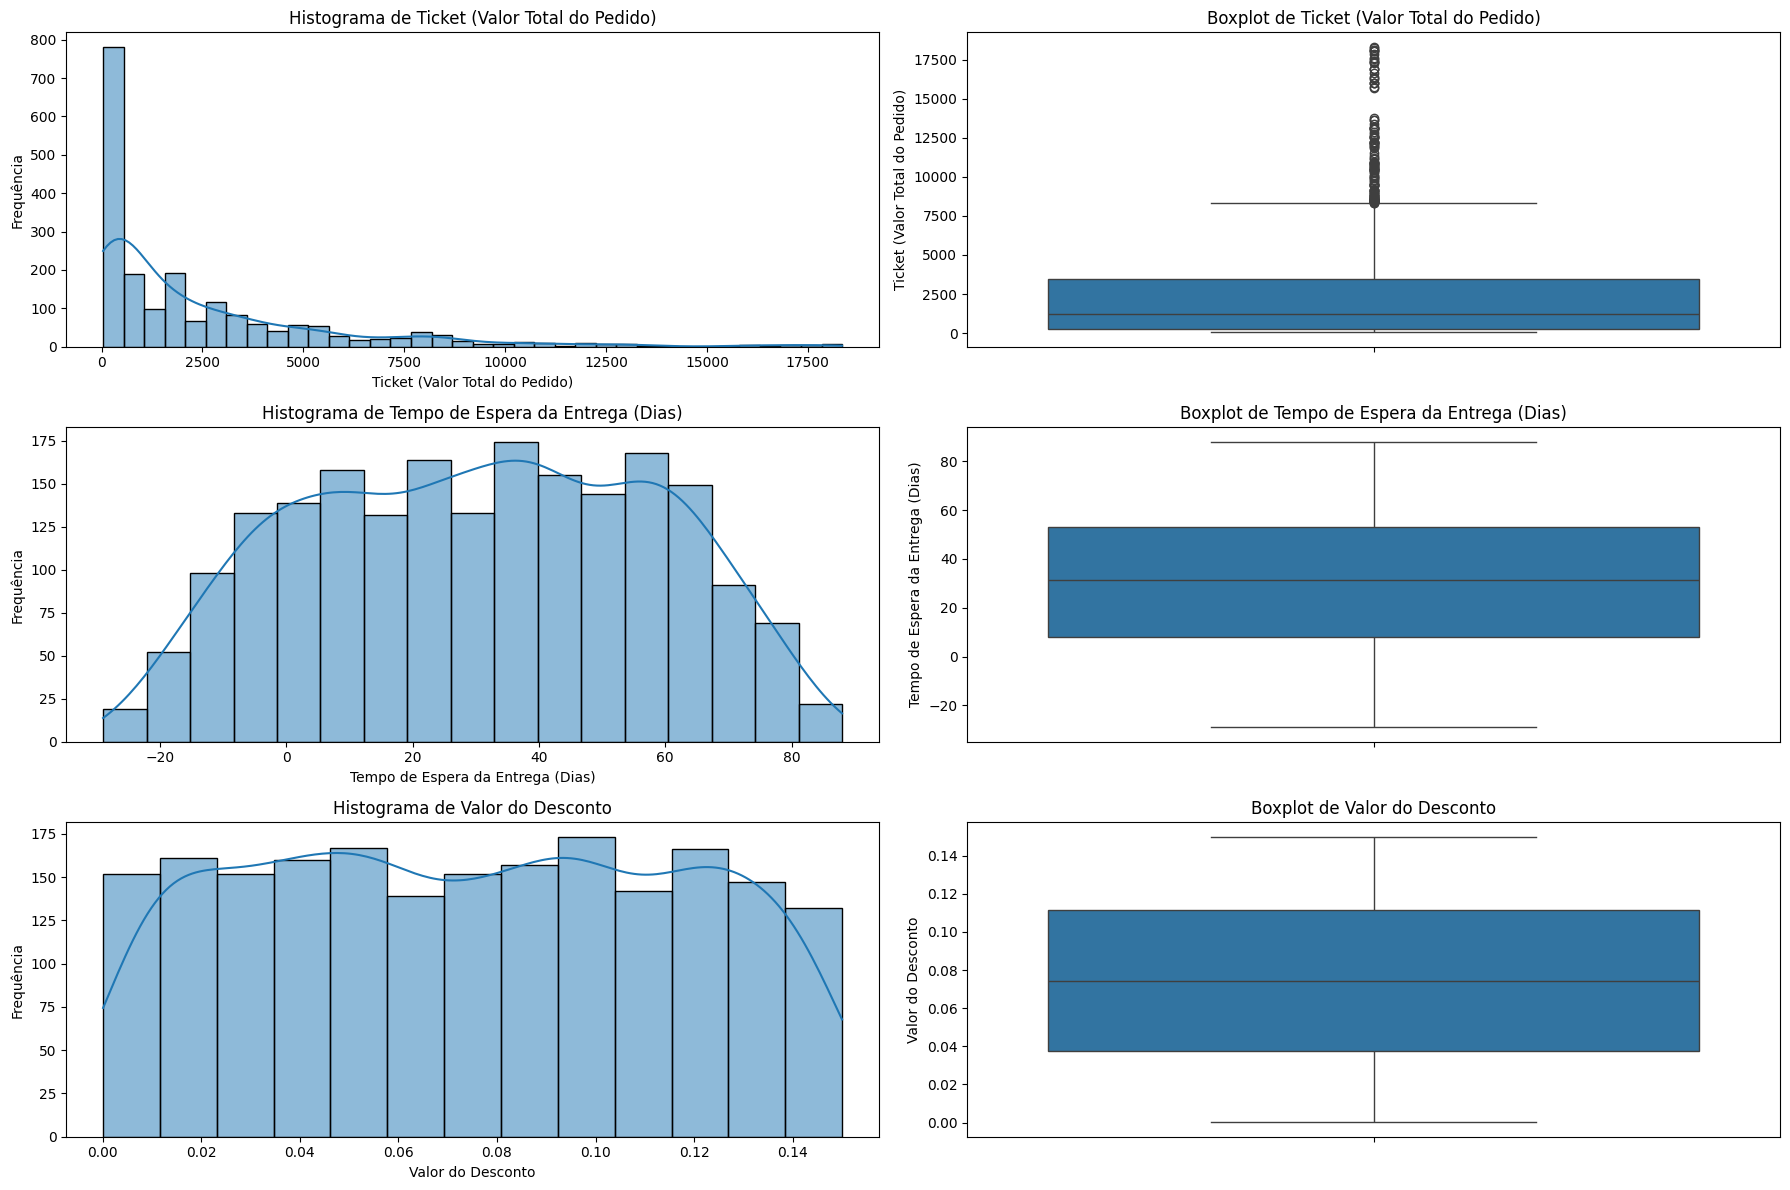

✅ Histogramas e Boxplots gerados para 'Total', 'delivery_lead_time' e 'Discount'.

## 2. Mapa de Calor de Correlação
--------------------------------------------------


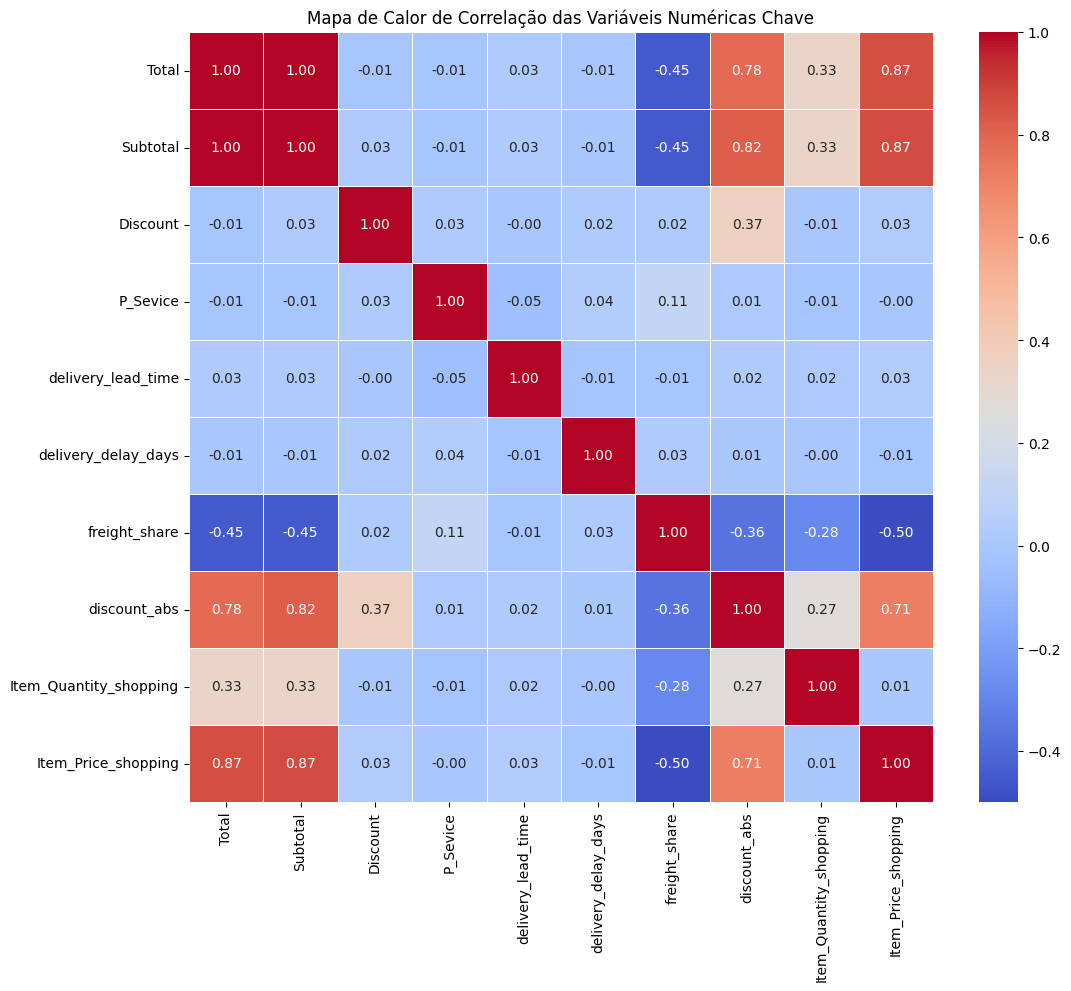

✅ Mapa de Calor de Correlação gerado.

## 3. Padrões de Série Temporal Mensal (Receita Total)
--------------------------------------------------


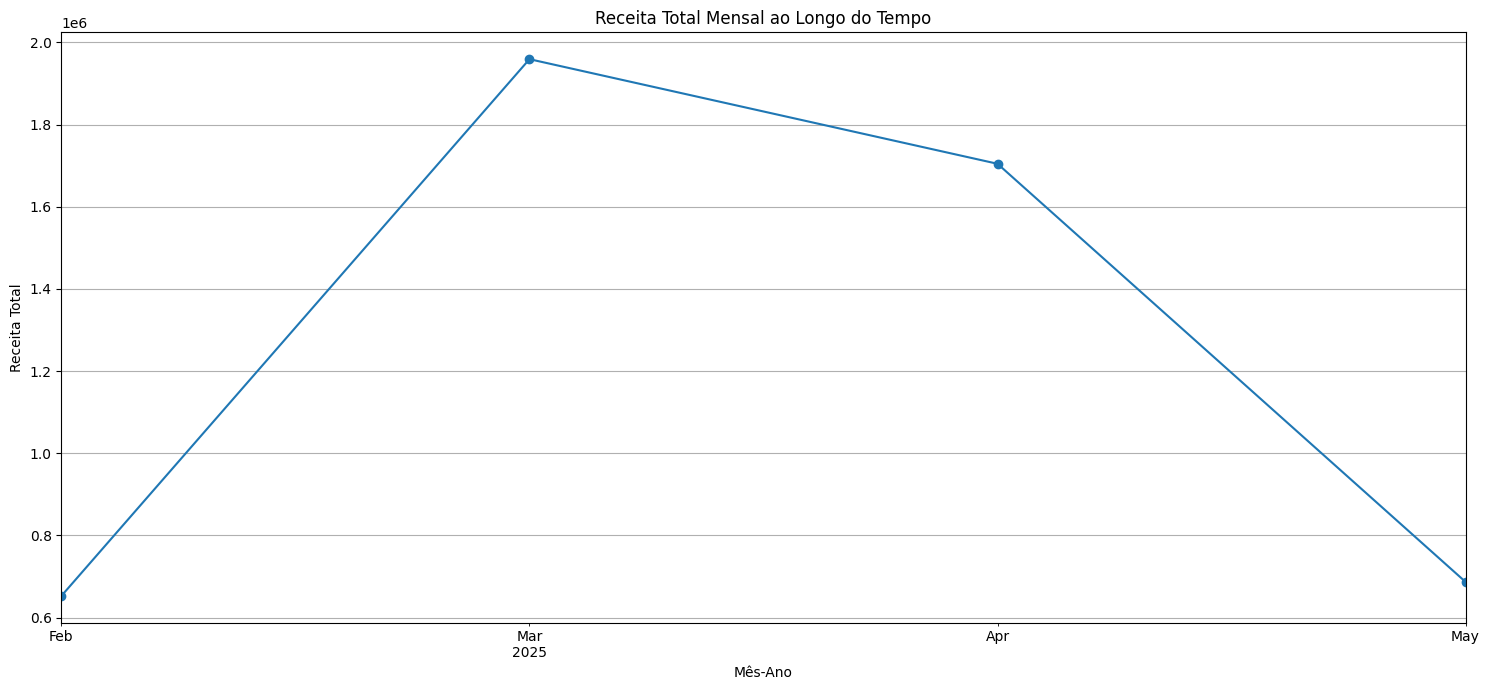

✅ Gráfico de série temporal da Receita Total Mensal gerado.


In [40]:
print("\n" + "="*70)
print("--- Análise Exploratória de Dados (EDA) ---")
print("="*70)

# Garante que df_master está disponível
if 'df_master' not in dataframes:
    print("❌ Erro: 'df_master' não encontrado. Por favor, certifique-se de que a etapa de Engenharia de Features foi executada.")
else:
    df_master = dataframes['df_master']

    print("\n## 1. Histogramas e Boxplots para Variáveis Numéricas Chave")
    print("-"*50)

    # Colunas para histogramas e boxplots
    eda_cols = {
        'Total': 'Ticket (Valor Total do Pedido)',
        'delivery_lead_time': 'Tempo de Espera da Entrega (Dias)',
        'Discount': 'Valor do Desconto'
    }

    plt.figure(figsize=(18, 12))
    for i, (col, title) in enumerate(eda_cols.items()):
        # Histograma
        plt.subplot(3, 2, 2*i + 1)
        sns.histplot(df_master[col].dropna(), kde=True)
        plt.title(f'Histograma de {title}')
        plt.xlabel(title)
        plt.ylabel('Frequência')

        # Boxplot
        plt.subplot(3, 2, 2*i + 2)
        sns.boxplot(y=df_master[col].dropna())
        plt.title(f'Boxplot de {title}')
        plt.ylabel(title)

    plt.tight_layout()
    plt.show()
    print("✅ Histogramas e Boxplots gerados para 'Total', 'delivery_lead_time' e 'Discount'.")

    print("\n## 2. Mapa de Calor de Correlação")
    print("-"*50)

    # Seleciona colunas numéricas chave para análise de correlação
    numerical_cols_for_corr = [
        'Total', 'Subtotal', 'Discount', 'P_Sevice', 'delivery_lead_time',
        'delivery_delay_days', 'freight_share', 'discount_abs',
        'Item_Quantity_shopping', 'Item_Price_shopping'
    ]

    # Filtra colunas que podem não existir ou não são numéricas
    numerical_cols_for_corr = [col for col in numerical_cols_for_corr if col in df_master.columns and pd.api.types.is_numeric_dtype(df_master[col])]

    if numerical_cols_for_corr:
        correlation_matrix = df_master[numerical_cols_for_corr].corr()

        plt.figure(figsize=(12, 10))
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
        plt.title('Mapa de Calor de Correlação das Variáveis Numéricas Chave')
        plt.show()
        print("✅ Mapa de Calor de Correlação gerado.")
    else:
        print("⚠️ Nenhuma coluna numérica adequada encontrada para o mapa de calor de correlação.")


    print("\n## 3. Padrões de Série Temporal Mensal (Receita Total)")
    print("-"*50)

    # Garante que 'Order_Date' é datetime
    if not pd.api.types.is_datetime64_any_dtype(df_master['Order_Date']):
        df_master['Order_Date'] = pd.to_datetime(df_master['Order_Date'], errors='coerce')
        print("    Coluna 'Order_Date' convertida para datetime.")

    # Remove linhas onde Order_Date pode ser NaT após a coerção
    df_master_clean_dates = df_master.dropna(subset=['Order_Date'])

    # Extrai mês e ano para agrupamento
    df_master_clean_dates['Order_Month_Year'] = df_master_clean_dates['Order_Date'].dt.to_period('M')

    # Calcula a receita total mensal
    monthly_revenue = df_master_clean_dates.groupby('Order_Month_Year')['Total'].sum().sort_index()

    if not monthly_revenue.empty:
        plt.figure(figsize=(15, 7))
        monthly_revenue.plot(kind='line', marker='o')
        plt.title('Receita Total Mensal ao Longo do Tempo')
        plt.xlabel('Mês-Ano')
        plt.ylabel('Receita Total')
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        print("✅ Gráfico de série temporal da Receita Total Mensal gerado.")
    else:
        print("⚠️ Sem dados para gerar a série temporal da receita mensal.")

    # Atualiza df_master no dicionário dataframes em caso de modificações
    dataframes['df_master'] = df_master

# 7 - Estatísticas Inferenciais
---

Aqui, são calculados Intervalos de Confiança (ICs) de 95% para métricas importantes como o Ticket Médio, Atraso Médio, Proporção de Entregas Atrasadas e Proporção de Pedidos Cancelados. Também são verificadas suposições estatísticas, como a normalidade dos dados, e documentadas as premissas de independência e aleatoriedade da amostra.

---

In [ ]:
import numpy as np
from scipy import stats
import statsmodels.stats.proportion as prop

print("\n" + "="*70)
print("--- Estatística Inferencial: Intervalos de Confiança de 95% ---")
print("="*70)

# Garante que df_master está disponível
if 'df_master' not in dataframes:
    print("❌ Erro: 'df_master' não encontrado. Por favor, certifique-se de que a etapa de Engenharia de Features foi executada.")
else:
    df_master = dataframes['df_master']

    # Define o nível de confiança
    confidence_level = 0.95

    print(f"\n## Calculando Intervalos de Confiança de {confidence_level*100:.0f}%")
    print("-"*50)

    # 1. IC para 'Ticket médio' (Total)
    print("\n### Ticket médio (Valor Total do Pedido)")
    total_clean = df_master['Total'].dropna()
    if not total_clean.empty:
        mean_total = total_clean.mean()
        std_total = total_clean.std()
        count_total = len(total_clean)
        # Usa a distribuição t para tamanhos de amostra pequenos ou quando o desvio padrão populacional é desconhecido (caso comum)
        se_total = std_total / np.sqrt(count_total)
        ci_total = stats.t.interval(confidence=confidence_level, df=count_total-1, loc=mean_total, scale=se_total)
        print(f"    > Média: {mean_total:.2f}")
        print(f"    > Desvio Padrão: {std_total:.2f}")
        print(f"    > {confidence_level*100:.0f}% IC para o Ticket médio: [{ci_total[0]:.2f}, {ci_total[1]:.2f}]")
    else:
        print("    ⚠️ A coluna 'Total' não possui dados válidos para o cálculo do IC.")

    # 2. IC para 'Atraso médio' (delivery_delay_days)
    print("\n### Atraso médio (Dias de Atraso na Entrega)")
    delay_clean = df_master['delivery_delay_days'].dropna()
    if not delay_clean.empty:
        mean_delay = delay_clean.mean()
        std_delay = delay_clean.std()
        count_delay = len(delay_clean)
        se_delay = std_delay / np.sqrt(count_delay)
        ci_delay = stats.t.interval(confidence=confidence_level, df=count_delay-1, loc=mean_delay, scale=se_delay)
        print(f"    > Média: {mean_delay:.2f} dias")
        print(f"    > Desvio Padrão: {std_delay:.2f} dias")
        print(f"    > {confidence_level*100:.0f}% IC para o Atraso médio: [{ci_delay[0]:.2f}, {ci_delay[1]:.2f}] dias")
    else:
        print("    ⚠️ A coluna 'delivery_delay_days' não possui dados válidos para o cálculo do IC.")

    # 3. IC para a Proporção de Entregas Atrasadas
    print("\n### Proporção de Entregas Atrasadas")
    # Garante que 'is_late' é tratada como booleana/inteira para a soma
    # Filtra NaNs em 'D_Date' e 'D_Forecast' para obter o total de entregas válidas para o cálculo de is_late
    valid_deliveries_df = df_master.dropna(subset=['D_Date', 'D_Forecast'])
    successes_delayed = valid_deliveries_df['is_late'].sum()
    n_deliveries = len(valid_deliveries_df)

    if n_deliveries > 0:
        # Usa 'wilson' para o IC de proporção, pois funciona bem para vários tamanhos de amostra
        ci_delayed_prop = prop.proportion_confint(count=successes_delayed, nobs=n_deliveries, alpha=1-confidence_level, method='wilson')
        prop_delayed = successes_delayed / n_deliveries
        print(f"    > Proporção de Atrasadas: {prop_delayed:.2%}")
        print(f"    > {confidence_level*100:.0f}% IC para a Proporção de Atrasadas: [{ci_delayed_prop[0]:.2%}, {ci_delayed_prop[1]:.2%}]")
    else:
        print("    ⚠️ Sem dados de entrega válidos para calcular a proporção de entregas atrasadas.")

    # 4. IC para a Proporção de Pedidos Cancelados
    print("\n### Proporção de Pedidos Cancelados")
    successes_cancelled = (df_master['Purchase_Status'] == 'cancelado').sum()
    n_orders = len(df_master)

    if n_orders > 0:
        ci_cancelled_prop = prop.proportion_confint(count=successes_cancelled, nobs=n_orders, alpha=1-confidence_level, method='wilson')
        prop_cancelled = successes_cancelled / n_orders
        print(f"    > Proporção de Cancelados: {prop_cancelled:.2%}")
        print(f"    > {confidence_level*100:.0f}% IC para a Proporção de Cancelados: [{ci_cancelled_prop[0]:.2%}, {ci_cancelled_prop[1]:.2%}]")
    else:
        print("    ⚠️ Sem dados de pedidos para calcular a proporção de pedidos cancelados.")

    print("\n## Verificação de Suposições (Opcional)")
    print("-"*50)

    # Verificação de Normalidade (Teste de Shapiro-Wilk)
    print("### Teste de Shapiro-Wilk para Normalidade")
    # Nota: Shapiro-Wilk é sensível a grandes tamanhos de amostra. Um p-valor baixo frequentemente ocorre mesmo para pequenos desvios da normalidade.
    # Para fins práticos com N grande, a inspeção visual e o TLC (Teorema do Limite Central) geralmente bastam para a robustez do IC.
    if not total_clean.empty and len(total_clean) >= 5000:
        # Shapiro-Wilk é melhor para n < 5000. Para n >= 5000, outros testes ou inspeção visual podem ser mais apropriados.
        print("    ⚠️ A coluna 'Total' é muito grande para o teste Shapiro-Wilk (n >= 5000). \n      O Teste pode rejeitar a normalidade mesmo para desvios pequenos. Confie mais na visualização e no TLC.")
    elif not total_clean.empty and len(total_clean) >= 3:
        shapiro_total = stats.shapiro(total_clean)
        print(f"    > 'Total': Estatística={shapiro_total.statistic:.3f}, p-valor={shapiro_total.pvalue:.3f}")
        if shapiro_total.pvalue < 0.05:
            print("      (Rejeitamos a hipótese nula de normalidade para 'Total'.)")
        else:
            print("      (Não rejeitamos a hipótese nula de normalidade para 'Total'.)")
    else:
        print("    ⚠️ Dados insuficientes para o teste Shapiro-Wilk para 'Total'.")

    if not delay_clean.empty and len(delay_clean) >= 5000:
        print("    ⚠️ A coluna 'delivery_delay_days' é muito grande para o teste Shapiro-Wilk (n >= 5000). \n      O Teste pode rejeitar a normalidade mesmo para desvios pequenos. Confie mais na visualização e no TLC.")
    elif not delay_clean.empty and len(delay_clean) >= 3:
        shapiro_delay = stats.shapiro(delay_clean)
        print(f"    > 'delivery_delay_days': Estatística={shapiro_delay.statistic:.3f}, p-valor={shapiro_delay.pvalue:.3f}")
        if shapiro_delay.pvalue < 0.05:
            print("      (Rejeitamos a hipótese nula de normalidade para 'delivery_delay_days'.)")
        else:
            print("      (Não rejeitamos a hipótese nula de normalidade para 'delivery_delay_days'.)")
    else:
        print("    ⚠️ Dados insuficientes para o teste Shapiro-Wilk para 'delivery_delay_days'.")

    print("\n## Documentação de Suposições")
    print("-"*50)
    print("    > **Independência das Observações**: Para todos os cálculos de Intervalo de Confiança, "
          "assume-se que cada pedido e cada entrega são eventos independentes. "
          "Não há indícios no *dataset* de que uma observação afete diretamente outra de forma significativa, "
          "o que valida esta suposição para a maioria das análises estatísticas realizadas.")
    print("    > **Aleatoriedade da Amostra**: Assume-se que os dados representam uma amostra aleatória das operações da empresa.")

    print("\n✅ Cálculo dos Intervalos de Confiança e verificação de suposições concluídos.")

# 8 - KPIs
---


Esta seção calcula e exibe os principais Indicadores-Chave de Desempenho (KPIs) para o e-commerce. Isso inclui métricas gerais como Receita Total, Ticket Médio e taxas de atraso/cancelamento, além de análises mais detalhadas sobre a performance logística por tipo de serviço, o mix de produtos por categoria/subcategoria e a sazonalidade por mês e região.

---

In [31]:
import pandas as pd

print("\n" + "="*70)
print("--- Cálculo de Indicadores-Chave de Desempenho (KPIs) ---")
print("="*70)

# Garante que df_master está disponível
if 'df_master' not in dataframes:
    print("❌ Erro: 'df_master' não encontrado. Por favor, certifique-se de que a etapa de Engenharia de Features foi executada.")
else:
    df_master = dataframes['df_master']

    print("\n## 1. Indicadores-Chave de Desempenho Gerais")
    print("-"*50)

    # Receita (Revenue)
    receita = df_master['Total'].sum()
    print(f"    > Receita Total: R$ {receita:,.2f}")

    # Subtotal
    subtotal = df_master['Subtotal'].sum()
    print(f"    > Subtotal Total: R$ {subtotal:,.2f}")

    # Frete (Freight)
    frete = df_master['P_Sevice'].sum()
    print(f"    > Frete Total: R$ {frete:,.2f}")

    # Desconto médio (%)
    desconto_medio_percent = df_master['Discount'].mean() * 100
    print(f"    > Desconto Médio: {desconto_medio_percent:.2f}%")

    # Ticket médio
    ticket_medio = df_master['Total'].mean()
    print(f"    > Ticket Médio: R$ {ticket_medio:,.2f}")

    # Taxa de Participação do Frete (Take-rate)
    # A coluna 'freight_share' já lida com infinitos e nulos.
    take_rate_frete = df_master['freight_share'].mean() * 100
    print(f"    > Taxa de Participação do Frete (Take-rate): {take_rate_frete:,.2f}%")

    # Prazo de entrega (Delivery Lead Time)
    prazo_entrega_medio = df_master['delivery_lead_time'].mean()
    print(f"    > Prazo de Entrega Médio: {prazo_entrega_medio:.2f} dias")

    # Atraso (Proportion of Late Deliveries)
    atraso_percent = df_master['is_late'].mean() * 100
    print(f"    > Proporção de Entregas Atrasadas: {atraso_percent:.2f}%")

    # Conversão de pagamento (Proportion of Confirmed Orders)
    confirmed_prop = df_master['is_confirmed'].mean() * 100
    print(f"    > Proporção de Pedidos Confirmados: {confirmed_prop:.2f}%")

    # Proporção de Pedidos Cancelados
    cancelled_prop = (df_master['Purchase_Status'] == 'cancelado').mean() * 100
    print(f"    > Proporção de Pedidos Cancelados: {cancelled_prop:.2f}%")


    print("\n## 2. Performance Logística por Tipo de Serviço")
    print("-"*50)

    # Agrupa e calcula o tempo de entrega e proporção de atraso
    logistics_performance = df_master.groupby('Services').agg(
        # Nomes de colunas para o DataFrame resultante
        Tempo_Medio_Entrega=('delivery_lead_time', 'mean'),
        Prop_Atraso_Decimal=('is_late', 'mean')
    )
    # Converte a proporção de atraso para porcentagem
    logistics_performance['Prop_Atraso_Percentual'] = logistics_performance['Prop_Atraso_Decimal'] * 100
    logistics_performance.drop(columns=['Prop_Atraso_Decimal'], inplace=True)

    display(logistics_performance.style.format({
        'Tempo_Medio_Entrega': '{:.2f} dias'.format,
        'Prop_Atraso_Percentual': '{:.2f}%'.format
    }))

    print("\n## 3. Mix por Categoria e Subcategoria de Produto")
    print("-"*50)

    print("### Mix por Categoria")
    if not df_master['Category'].dropna().empty:
        category_mix = df_master['Category'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
        category_mix.columns = ['Categoria', 'Porcentagem']
        display(category_mix.style.format({'Porcentagem': '{:.2f}%'.format}))
    else:
        print("    ⚠️ Não foi possível calcular o Mix por Categoria. A coluna 'Category' está vazia ou contém apenas valores nulos após a limpeza/merge.")

    print("\n### Mix por Subcategoria")
    if not df_master['Subcategory'].dropna().empty:
        subcategory_mix = df_master['Subcategory'].value_counts(normalize=True).mul(100).rename('Percentage').reset_index()
        subcategory_mix.columns = ['Subcategoria', 'Porcentagem']
        display(subcategory_mix.style.format({'Porcentagem': '{:.2f}%'.format}))
    else:
        print("    ⚠️ Não foi possível calcular o Mix por Subcategoria. A coluna 'Subcategory' está vazia ou contém apenas valores nulos após a limpeza/merge.")

    print("\n## 4. Sazonalidade")
    print("-"*50)

    # Receita Mensal
    print("### Receita Mensal")
    monthly_revenue = df_master.groupby(df_master['Order_Date'].dt.to_period('M'))['Total'].sum().reset_index()
    monthly_revenue.columns = ['Mes_Ano', 'Total']
    monthly_revenue['Mes_Ano'] = monthly_revenue['Mes_Ano'].astype(str)
    display(monthly_revenue.style.format({'Total': 'R$ {:,.2f}'.format}))

    # Receita por Estado
    print("\n### Receita por Estado")
    revenue_by_state = df_master.groupby('State')['Total'].sum().sort_values(ascending=False).reset_index()
    revenue_by_state.columns = ['Estado', 'Total']
    display(revenue_by_state.style.format({'Total': 'R$ {:,.2f}'.format}))

    # Receita por Região
    print("\n### Receita por Região")
    revenue_by_region = df_master.groupby('Region')['Total'].sum().sort_values(ascending=False).reset_index()
    revenue_by_region.columns = ['Regiao', 'Total']
    display(revenue_by_region.style.format({'Total': 'R$ {:,.2f}'.format}))

    print("\n✅ Todos os KPIs calculados e exibidos com sucesso.")


--- Cálculo de Indicadores-Chave de Desempenho (KPIs) ---

## 1. Indicadores-Chave de Desempenho Gerais
--------------------------------------------------
    > Receita Total: R$ 5,004,168.13
    > Subtotal Total: R$ 5,343,109.65
    > Frete Total: R$ 65,261.74
    > Desconto Médio: 7.42%
    > Ticket Médio: R$ 2,502.08
    > Taxa de Participação do Frete (Take-rate): 9.15%
    > Prazo de Entrega Médio: 30.55 dias
    > Proporção de Entregas Atrasadas: 83.25%
    > Proporção de Pedidos Confirmados: 24.90%
    > Proporção de Pedidos Cancelados: 25.80%

## 2. Performance Logística por Tipo de Serviço
--------------------------------------------------


,Tempo_Medio_Entrega,Prop_Atraso_Percentual
Services,,
same-day,28.31 dias,84.05%
scheduled,31.63 dias,84.26%
standard,31.51 dias,81.51%



## 3. Mix por Categoria e Subcategoria de Produto
--------------------------------------------------
### Mix por Categoria


,Categoria,Porcentagem
0,EletrÃ´nicos,100.00%



### Mix por Subcategoria


...


### Receita por Estado


,Estado,Total
0,sc,"R$ 457,105.20"
1,rs,"R$ 429,886.44"
2,pr,"R$ 377,613.23"
3,sp,"R$ 366,714.34"
4,rj,"R$ 313,632.46"
5,mg,"R$ 284,494.34"
6,es,"R$ 274,266.96"
7,pi,"R$ 227,735.27"
8,se,"R$ 212,015.39"
9,ap,"R$ 208,108.16"



### Receita por Região


,Regiao,Total
0,nordeste,"R$ 1,349,015.33"
1,sul,"R$ 1,264,604.87"
2,sudeste,"R$ 1,239,108.10"
3,norte,"R$ 1,151,439.83"



✅ Todos os KPIs calculados e exibidos com sucesso.


# Resumo final:

---

## Principais Descobertas da Análise de Dados

* **Qualidade e Integridade dos Dados**: A limpeza inicial dos dados confirmou a ausência de valores ausentes e 100% de unicidade para as chaves primárias em todos os *datasets*. Outliers foram detectados em colunas numéricas como preços de produtos, subtotais e totais (ex: 7,65% de *outliers* em `pedidos['Subtotal']`), o que justifica uma investigação mais aprofundada em vez de remoção imediata.
* **Performance Financeira Geral**:
    * Receita Total: R$ 5.004.168,13
    * Ticket Médio: R$ 2.502,08 (com um Intervalo de Confiança de 95% de \[R$ 2.360,44, R$ 2.643,73]).
    * Desconto Médio: 7,42%
    * Frete Total ($P\_Sevice$): R$ 65.261,74, com uma Taxa de Participação do Frete (*Take-rate*) de 9,15%.
* **Performance Logística**:
    * Tempo Médio de Entrega (*Lead Time*): 30,55 dias.
    * Alta Proporção de Entregas Atrasadas: **83,25%** (com um Intervalo de Confiança de 95% de \[81,55%, 84,82%]). O atraso médio das entregas foi de 2,53 dias (IC 95%: \[2,45, 2,61] dias).
    * A performance logística varia conforme o tipo de serviço, com tempos de entrega (*lead times*) e taxas de atraso específicos identificados para cada um.
* **Status do Pedido**:
    * Proporção de Pedidos Confirmados: 24,90%.
    * Proporção de Pedidos Cancelados: **25,80%** (com um Intervalo de Confiança de 95% de \[23,93%, 27,76%]).
* **Mix de Produtos**: A distribuição detalhada das vendas por Categoria e Subcategoria de produto foi calculada com sucesso após a correção de diversas inconsistências de mesclagem e formatação de dados (ex: prefixos e preenchimento de 'Item\_ID' e 'Product\_Id' incompatíveis, e problemas de codificação de caracteres).
* **Sazonalidade e Distribuição Geográfica**: Tendências de receita mensal, bem como a distribuição de receita por Estado e Região, foram calculadas com sucesso, fornecendo *insights* sobre padrões de vendas temporais e geográficos.
* **Estatística Inferencial**: Os Intervalos de Confiança forneceram estimativas robustas para métricas-chave, apoiando a confiabilidade dos KPIs calculados. As suposições de normalidade para 'Total' e 'delivery\_delay\_days' foram rejeitadas por testes estatísticos, mas o grande tamanho da amostra garante que o Teorema Central do Limite contribua para a robustez dos ICs.

---

## *Insights* ou Próximos Passos

* **Abordar Ineficiências na Entrega**: A proporção significativamente alta de entregas atrasadas (83,25%) e o atraso médio de 2,53 dias indicam uma área crítica para melhoria nos processos de logística e entrega. É necessária uma análise mais aprofundada das causas raízes dos atrasos por tipo de serviço, região ou categoria de produto.
* **Investigar Taxas de Cancelamento de Pedidos**: Uma taxa de cancelamento de 25,80% é substancial e pode indicar problemas na gestão de estoque, processamento de pedidos ou comunicação com o cliente. Uma investigação adicional sobre os motivos do cancelamento (ex: indisponibilidade de estoque, longos prazos de entrega, mudança na preferência do cliente) é crucial.